# Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
df = pd.read_csv('RegData.csv')

In [ ]:
df.head()

,StID,SAT,GPA
0,101,1355,3.42
1,102,1391,3.48
2,103,1170,2.91
3,104,1357,3.41
4,105,1326,3.28


In [ ]:
X = df["SAT"]
Y = df["GPA"]


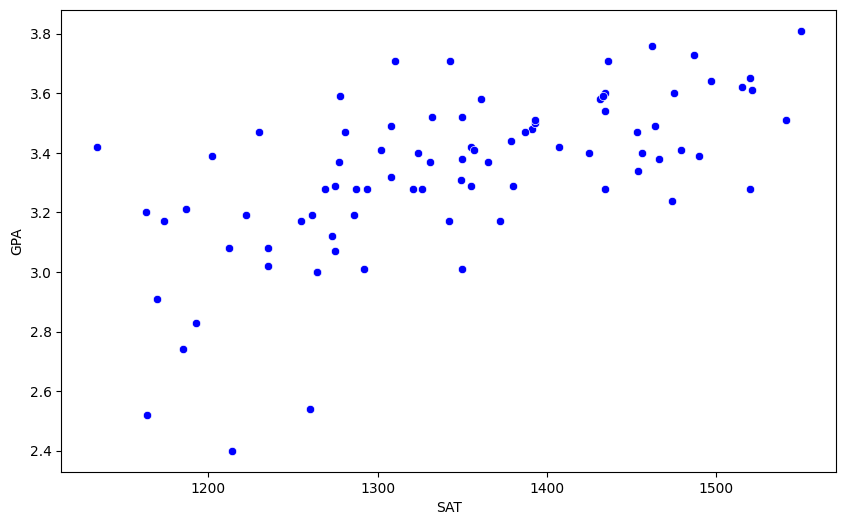

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x =X, y=Y, color="blue")
plt.xlabel("SAT")
plt.ylabel("GPA")
plt.show()

In [ ]:
corr = df[["SAT", "GPA"]].corr()

<Axes: >

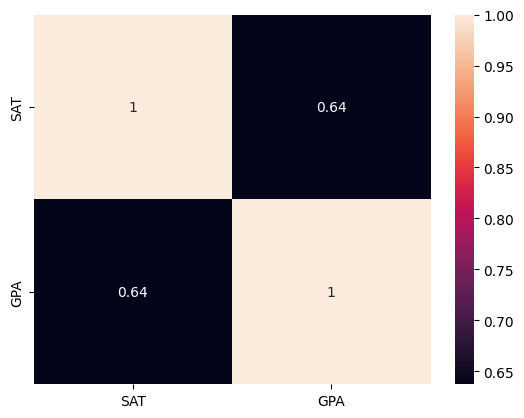

In [ ]:
sns.heatmap(corr, annot=True)

In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(X,Y)

In [ ]:
print(f"Slope : {slope}")
print(f"Intercept : {intercept}")
print(f"Y = {round(slope, 3)}X + {round(intercept, 2)}")

Slope : 0.001655688050092813
Intercept : 1.1028843247066882
Y = 0.002X + 1.1


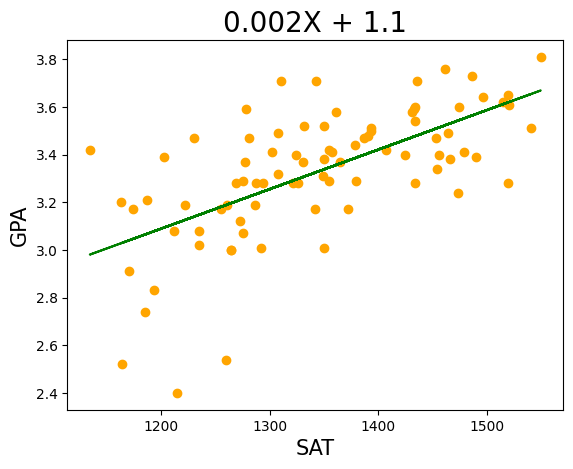

In [ ]:
y1 = slope*X + intercept
plt.scatter(X, Y, color="orange")
plt.plot(X, y1, color="green")
plt.xlabel("SAT", fontsize=15)
plt.ylabel("GPA", fontsize=15)
plt.title(f"{round(slope, 3)}X + {round(intercept, 2)}", fontsize=20)
plt.show()

## Prediction

In [ ]:
givenSAT = 1450
predGPA = slope*givenSAT + intercept
predGPA

np.float64(3.503631997341267)

In [ ]:
y2 = df["GPA"]
df_pred = pd.DataFrame({"Actual Data" : y2, "Predicted Data": round(y1,2)})
df_pred.head()

,Actual Data,Predicted Data
0,3.42,3.35
1,3.48,3.41
2,2.91,3.04
3,3.41,3.35
4,3.28,3.30


<Axes: >

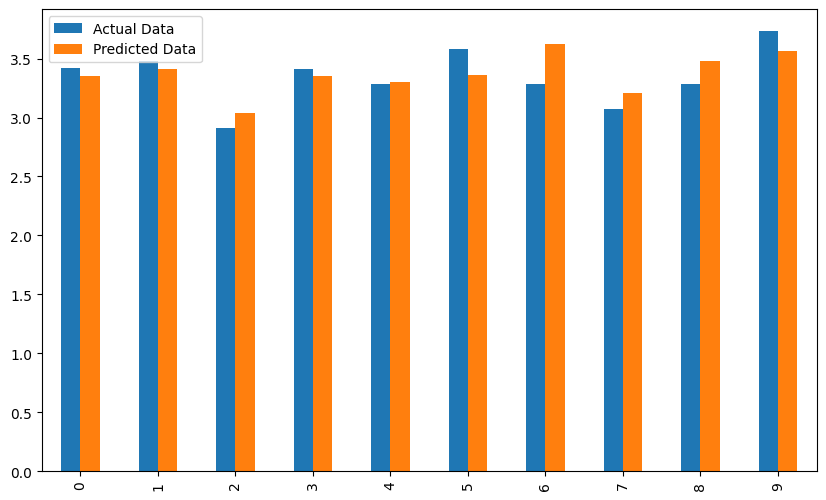

In [ ]:
df_pred.head(10).plot(kind="bar", figsize=(10,6))

In [ ]:
df_1_p = pd.DataFrame({**df, "PredictedGPA" : y1})
df_1_p

,StID,SAT,GPA,PredictedGPA
0,101,1355,3.42,3.346342
1,102,1391,3.48,3.405946
2,103,1170,2.91,3.040039
3,104,1357,3.41,3.349653
4,105,1326,3.28,3.298327
...,...,...,...,...
79,193,1365,3.37,3.362899
80,195,1479,3.41,3.551647
81,196,1324,3.40,3.295015
82,197,1294,3.28,3.245345


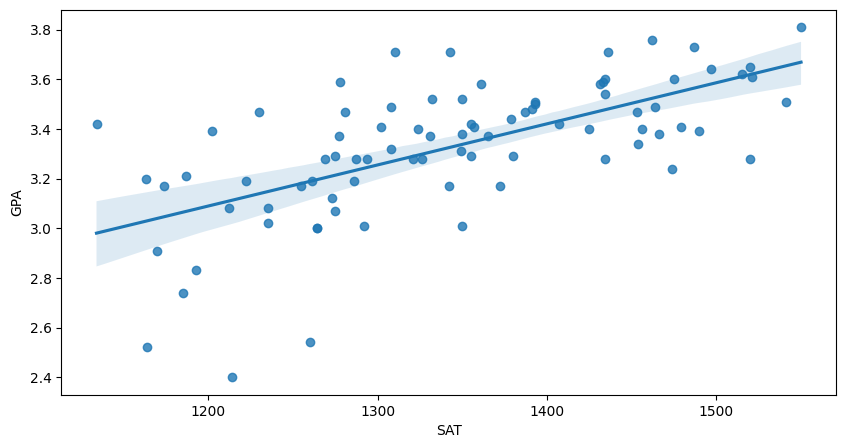

In [ ]:
plt.figure(figsize=(10,5))
p = sns.regplot(data=df, x=df["SAT"], y=df["GPA"])

<Axes: xlabel='SAT', ylabel='GPA'>

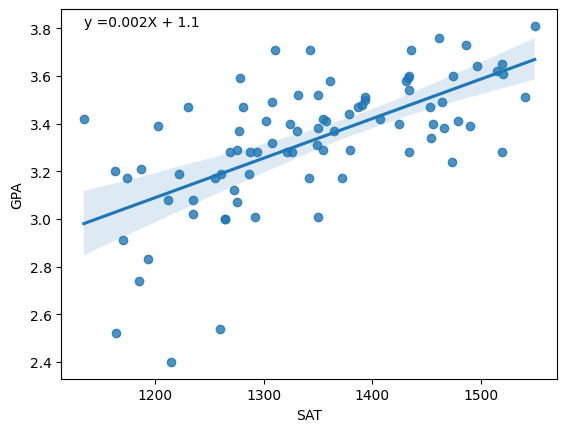

In [ ]:
plt.text(min(df["SAT"]), max(df["GPA"]), f"y ={round(slope, 3)}X + {round(intercept, 2)}")
sns.regplot(data=df, x=df["SAT"], y=df["GPA"])

In [ ]:
X = df[["SAT"]]
Y = df["GPA"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [ ]:
clf = LinearRegression()

In [ ]:
model = clf.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y = pd.DataFrame({"Actual" : y_test, "Predicted" : y_pred})
y.head()

,Actual,Predicted
10,3.01,3.270437
67,3.40,3.527507
59,2.52,3.069796
33,3.71,3.298652
83,3.44,3.406809


<Axes: >

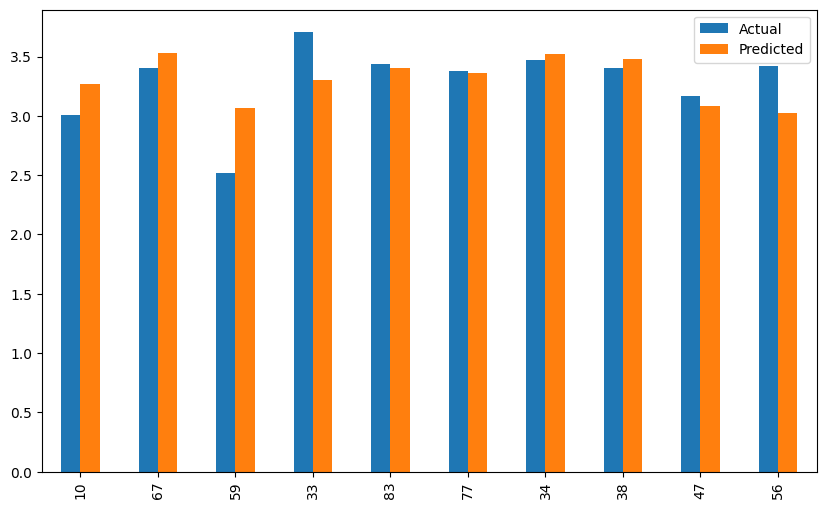

In [ ]:
y.head(10).plot(kind="bar", figsize=(10,6))

In [ ]:
print("MAE\t\t", metrics.mean_absolute_error(y_test, y_pred))
print("MSE\t\t", metrics.mean_squared_error(y_test, y_pred))
print("RMSE\t\t", metrics.mean_squared_error(y_test, y_pred)**0.5)
print("R_Squared\t", metrics.r2_score(y_test, y_pred))

MAE		 0.2054834292112158
MSE		 0.08052728657188303
RMSE		 0.28377330137256224
R_Squared	 0.3346446677333793


In [ ]:
model.score(x_test, y_test)

0.3346446677333793

If RMSE > MSE , There is high variation.

# Gradient Descent

In [ ]:
b0 =0
b1 = 0
learning_rate = 0.0000001
epochs =  1000
n = float(len(x_train))

In [ ]:
x_vals = x_train.values.flatten()
y_vals = y_train.to_numpy()
x_vals

array([1332, 1308, 1350, 1281, 1212, 1343, 1235, 1294, 1387, 1431, 1515,
       1350, 1255, 1357, 1393, 1497, 1550, 1277, 1163, 1393, 1434, 1230,
       1355, 1365, 1222, 1275, 1479, 1287, 1273, 1349, 1464, 1436, 1269,
       1235, 1380, 1264, 1454, 1326, 1433, 1275, 1475, 1407, 1321, 1434,
       1187, 1308, 1185, 1520, 1278, 1391, 1474, 1355, 1361, 1193, 1487,
       1264, 1302, 1261])

In [ ]:
for i in range(epochs):
    y_current = b1*x_vals + b0

    D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 = (-2/n) * sum(y_vals - y_current)
    b1 = b1 - learning_rate * D_b1
    b0 = b0 - learning_rate * D_b0
print(f"Final intercept (b0) : {b0}")
print(f"Final slope (b1) : {b1}")

Final intercept (b0) : 3.0909328257626908e-06
Final slope (b1) : 0.002489613858182571


In [ ]:
y_pred_gd = b1 * x_test + b0


In [ ]:
print("MAE\t\t", metrics.mean_absolute_error(y_test, y_pred_gd))
print("MSE\t\t", metrics.mean_squared_error(y_test, y_pred_gd))
print("RMSE\t\t", metrics.mean_squared_error(y_test, y_pred_gd)**0.5)
print("R_Squared\t", metrics.r2_score(y_test, y_pred_gd))

MAE		 0.231072026745874
MSE		 0.0865375579259598
RMSE		 0.29417266685734045
R_Squared	 0.2849849031486804
